In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
transactions = pd.read_csv("../data/raw/08_investor_transactions.csv")

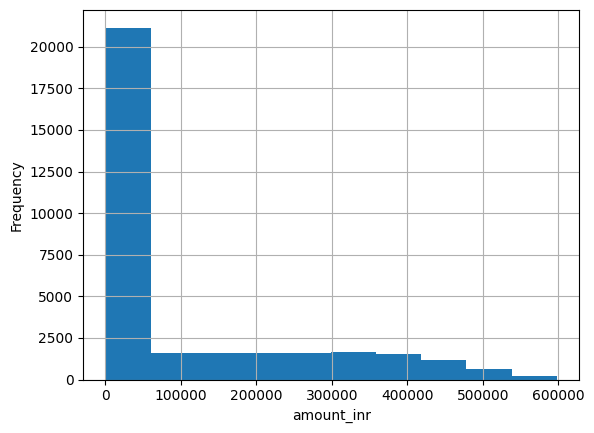

In [9]:
transactions["amount_inr"].hist()

plt.xlabel("amount_inr")
plt.ylabel("Frequency")
plt.show()

Text(0, 0.5, 'Investment')

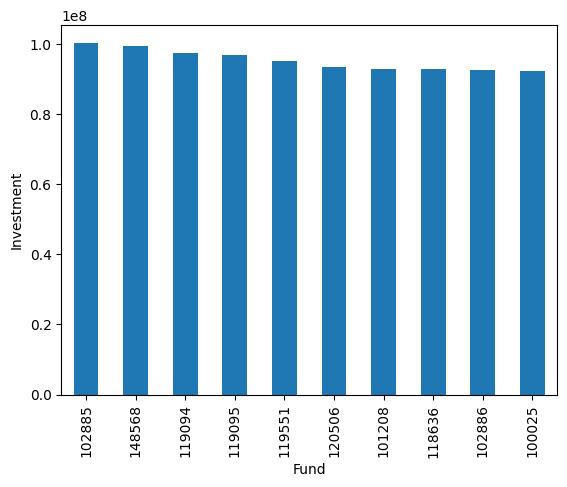

In [10]:
top_funds = (
    transactions.groupby("amfi_code")
    ["amount_inr"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
top_funds.plot(kind="bar")
plt.xlabel("Fund")
plt.ylabel("Investment")

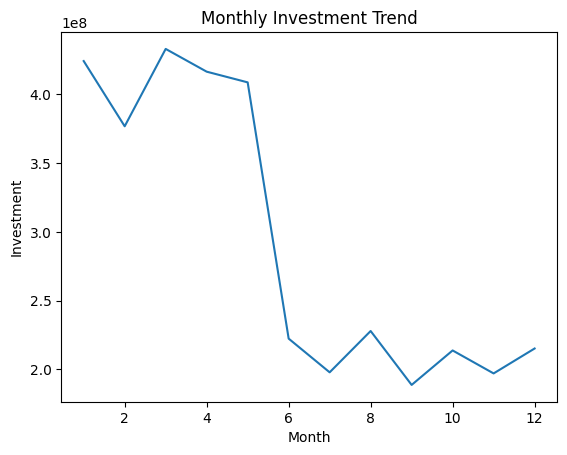

In [13]:
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)
monthly = (
    transactions.groupby(
        transactions["transaction_date"].dt.month
    )["amount_inr"]
    .sum()
)
monthly.plot(kind="line")
plt.title("Monthly Investment Trend")
plt.xlabel("Month")
plt.ylabel("Investment")
plt.show()

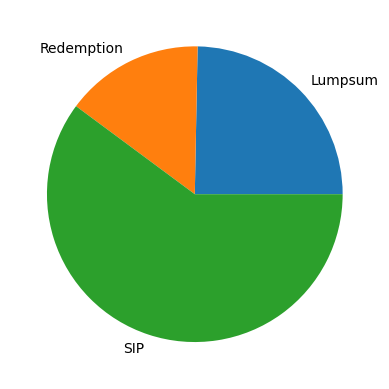

In [17]:
category = (
    transactions.groupby("transaction_type")
    .size()
)
category.plot(kind="pie")
plt.show()

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

In [5]:
nav = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")
nav['date'] = pd.to_datetime(nav['date'])
                  

In [7]:
nav.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [8]:
nav.info()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   amfi_code  46000 non-null  int64         
 1   date       46000 non-null  datetime64[us]
 2   nav        46000 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(1)
memory usage: 1.1 MB


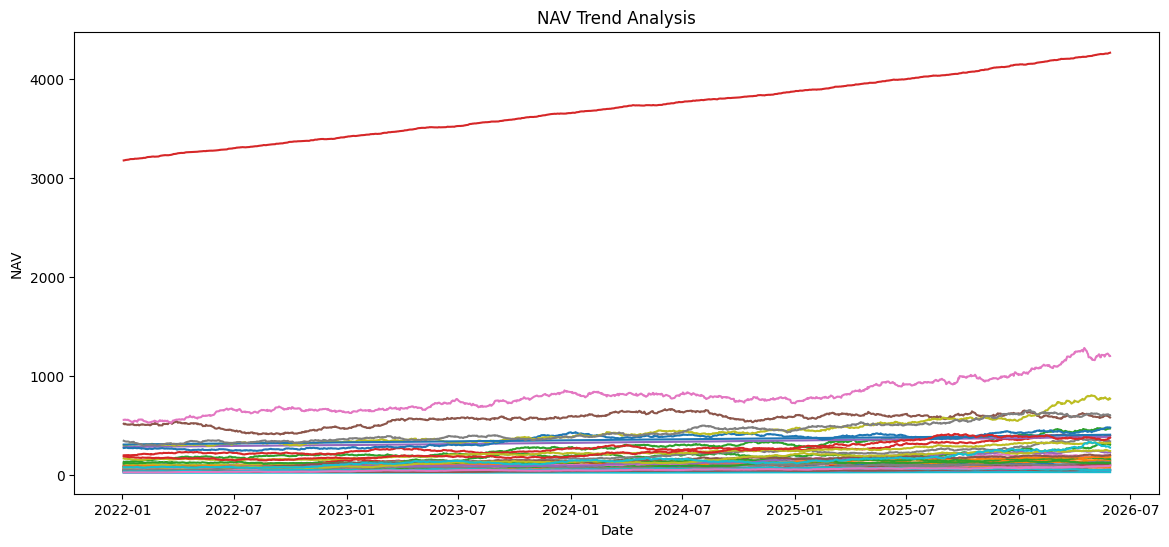

In [9]:
plt.figure(figsize=(14,6))

for scheme in nav['amfi_code'].unique():
    temp = nav[nav['amfi_code'] == scheme]
    plt.plot(temp['date'], temp['nav'])

plt.title("NAV Trend Analysis")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.show()

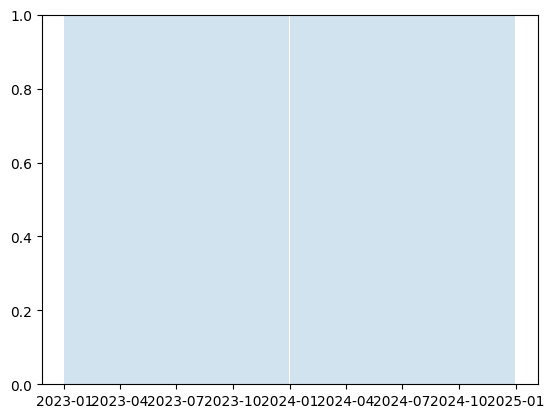

In [10]:
plt.axvspan(pd.Timestamp('2023-01-01'),
            pd.Timestamp('2023-12-31'),
            alpha=0.2)

plt.axvspan(pd.Timestamp('2024-01-01'),
            pd.Timestamp('2024-12-31'),
            alpha=0.2)

In [11]:
aum = pd.read_csv("../data/processed/03_aum_by_fund_house_cleaned.csv")

In [13]:
aum.info()

<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            90 non-null     str    
 1   fund_house      90 non-null     str    
 2   aum_lakh_crore  90 non-null     float64
 3   aum_crore       90 non-null     int64  
 4   num_schemes     90 non-null     int64  
dtypes: float64(1), int64(2), str(2)
memory usage: 3.6 KB


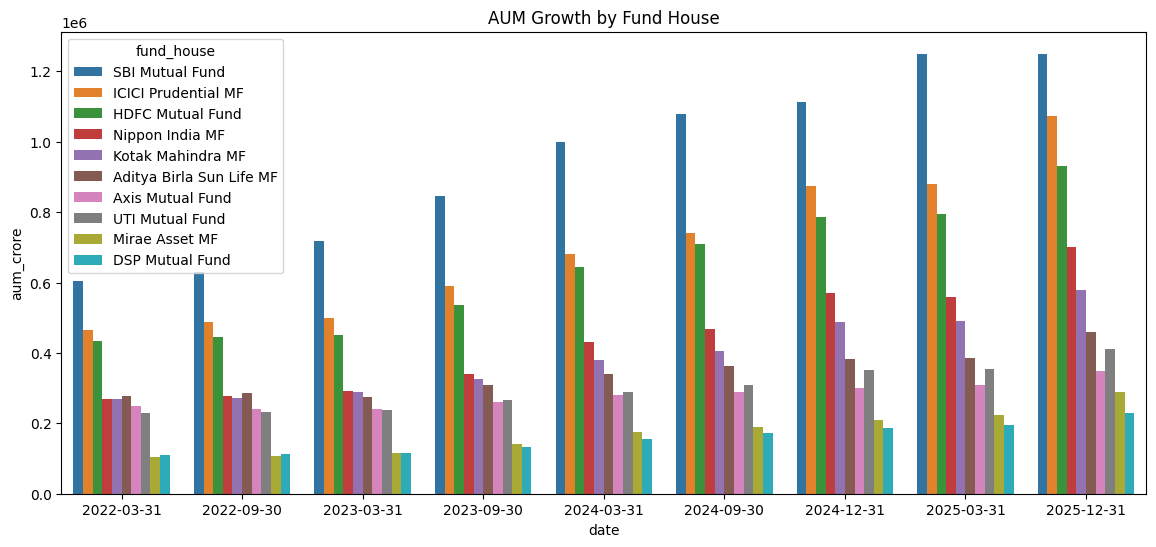

In [14]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=aum,
    x='date',
    y='aum_crore',
    hue='fund_house'
)

plt.title("AUM Growth by Fund House")
plt.show()

In [15]:
sip = pd.read_csv("../data/processed/04_monthly_sip_inflows_cleaned.csv")
sip['month'] = pd.to_datetime(sip['month'])

In [16]:
sip.info()

<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   month                      48 non-null     datetime64[us]
 1   sip_inflow_crore           48 non-null     int64         
 2   active_sip_accounts_crore  48 non-null     float64       
 3   new_sip_accounts_lakh      48 non-null     float64       
 4   sip_aum_lakh_crore         48 non-null     float64       
 5   yoy_growth_pct             36 non-null     float64       
dtypes: datetime64[us](1), float64(4), int64(1)
memory usage: 2.4 KB


In [20]:
fig = px.line(
    sip,
    x='month',
    y='sip_aum_lakh_crore',
    title='Monthly SIP Inflow'
)

fig.show()

In [21]:
fig.add_annotation(
    x='2025-12-01',
    y=31002,
    text='₹31,002 Cr All-Time High'
)

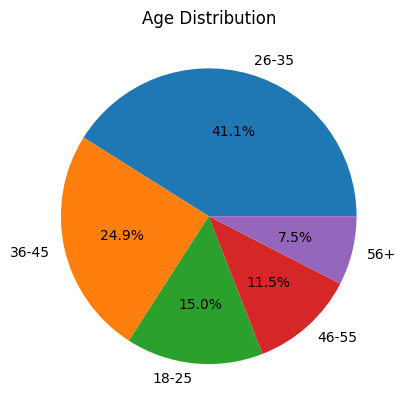

In [23]:
investors = pd.read_csv("../data/processed/08_investor_transactions_cleaned.csv")

age = investors['age_group'].value_counts()

plt.pie(
    age,
    labels=age.index,
    autopct='%1.1f%%'
)

plt.title("Age Distribution")
plt.show()

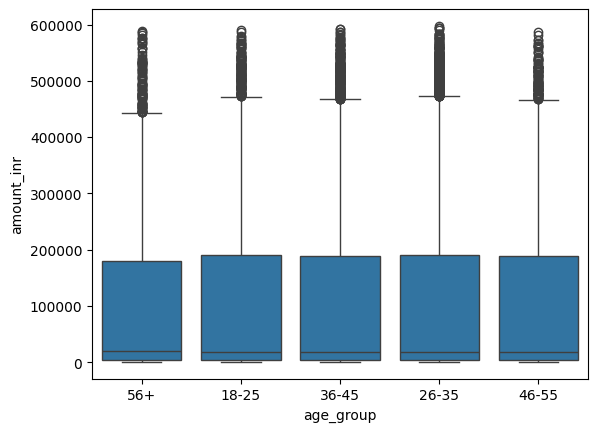

In [28]:
sns.boxplot(
    data=investors,
    x='age_group',
    y='amount_inr'
)

plt.show()

In [27]:
investors.info()

<class 'pandas.DataFrame'>
RangeIndex: 32778 entries, 0 to 32777
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   investor_id         32778 non-null  str    
 1   transaction_date    32778 non-null  str    
 2   amfi_code           32778 non-null  int64  
 3   transaction_type    32778 non-null  str    
 4   amount_inr          32778 non-null  int64  
 5   state               32778 non-null  str    
 6   city                32778 non-null  str    
 7   city_tier           32778 non-null  str    
 8   age_group           32778 non-null  str    
 9   gender              32778 non-null  str    
 10  annual_income_lakh  32778 non-null  float64
 11  payment_mode        32778 non-null  str    
 12  kyc_status          32778 non-null  str    
dtypes: float64(1), int64(2), str(10)
memory usage: 3.3 MB


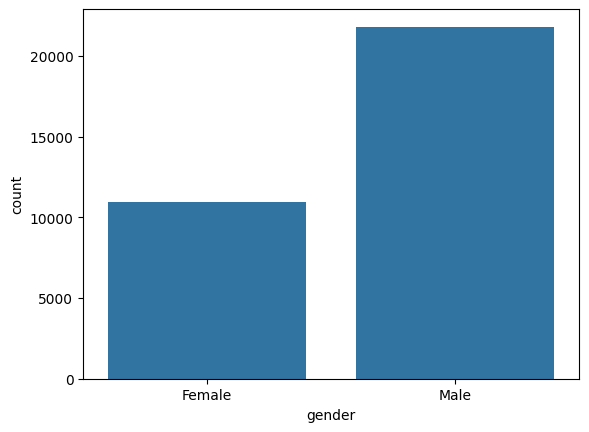

In [29]:
sns.countplot(
    data=investors,
    x='gender'
)

plt.show()

In [31]:
cat = pd.read_csv("../data/processed/05_category_inflows_cleaned.csv")

In [32]:
cat.info()

<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   month             144 non-null    str    
 1   category          144 non-null    str    
 2   net_inflow_crore  144 non-null    float64
dtypes: float64(1), str(2)
memory usage: 3.5 KB


In [33]:
heatmap_data = cat.pivot(
    index='category',
    columns='month',
    values='net_inflow_crore'
)

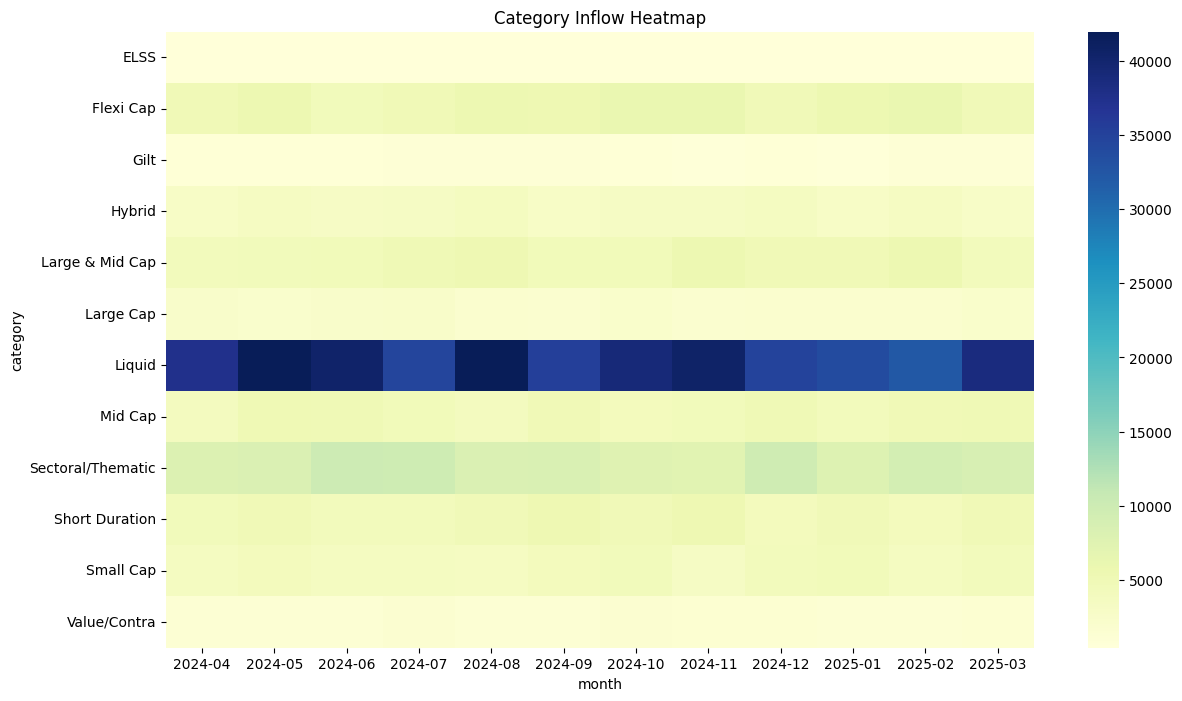

In [34]:
plt.figure(figsize=(14,8))

sns.heatmap(
    heatmap_data,
    cmap='YlGnBu'
)

plt.title("Category Inflow Heatmap")
plt.show()

In [36]:
state_sip = investors.groupby(
    'state'
)['amount_inr'].sum().sort_values()

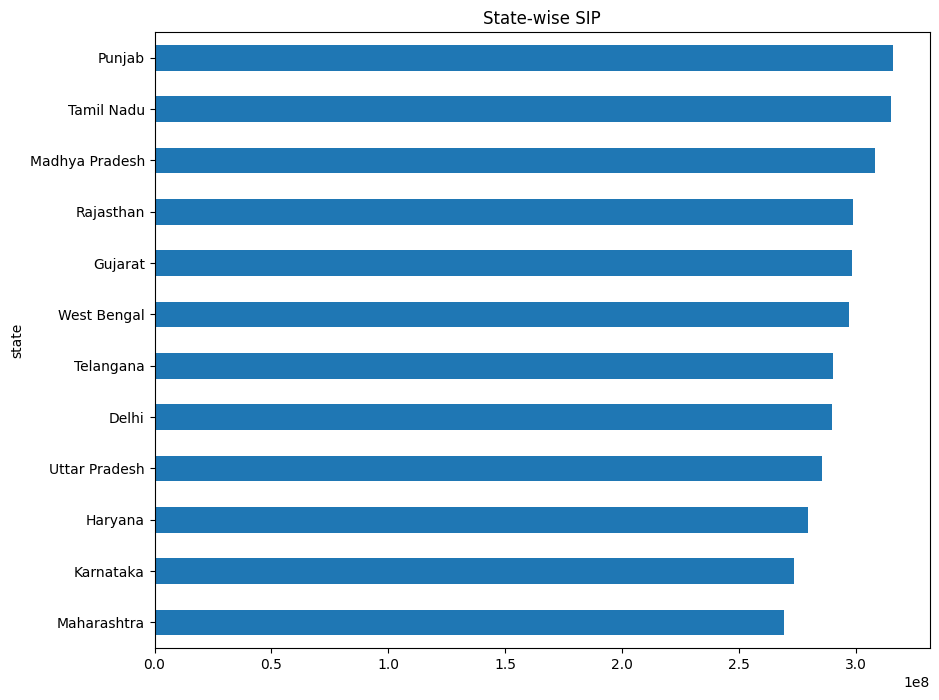

In [51]:
state_sip.plot(
    kind='barh',
    figsize=(10,8)
)

plt.title("State-wise SIP")
plt.show()

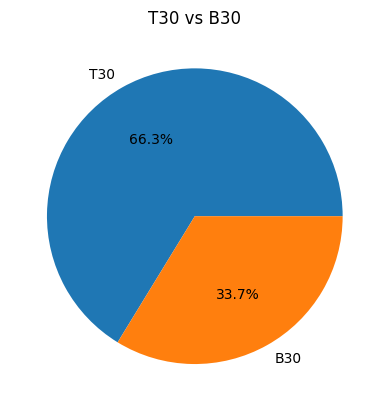

In [38]:
tier = investors['city_tier'].value_counts()

plt.pie(
    tier,
    labels=tier.index,
    autopct='%1.1f%%'
)

plt.title("T30 vs B30")
plt.show()

In [39]:
folio = pd.read_csv("../data/processed/06_industry_folio_count_cleaned.csv")

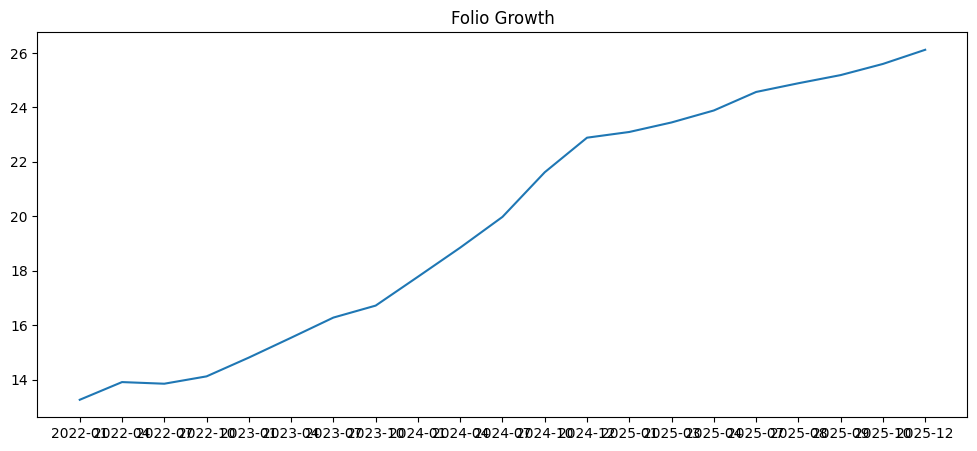

In [40]:
plt.figure(figsize=(12,5))

plt.plot(
    folio['month'],
    folio['total_folios_crore']
)

plt.title("Folio Growth")
plt.show()

In [43]:
pivot_nav = nav.pivot(
    index='date',
    columns='amfi_code',
    values='nav'
)

In [44]:
returns = pivot_nav.pct_change()

In [45]:
corr = returns.corr()

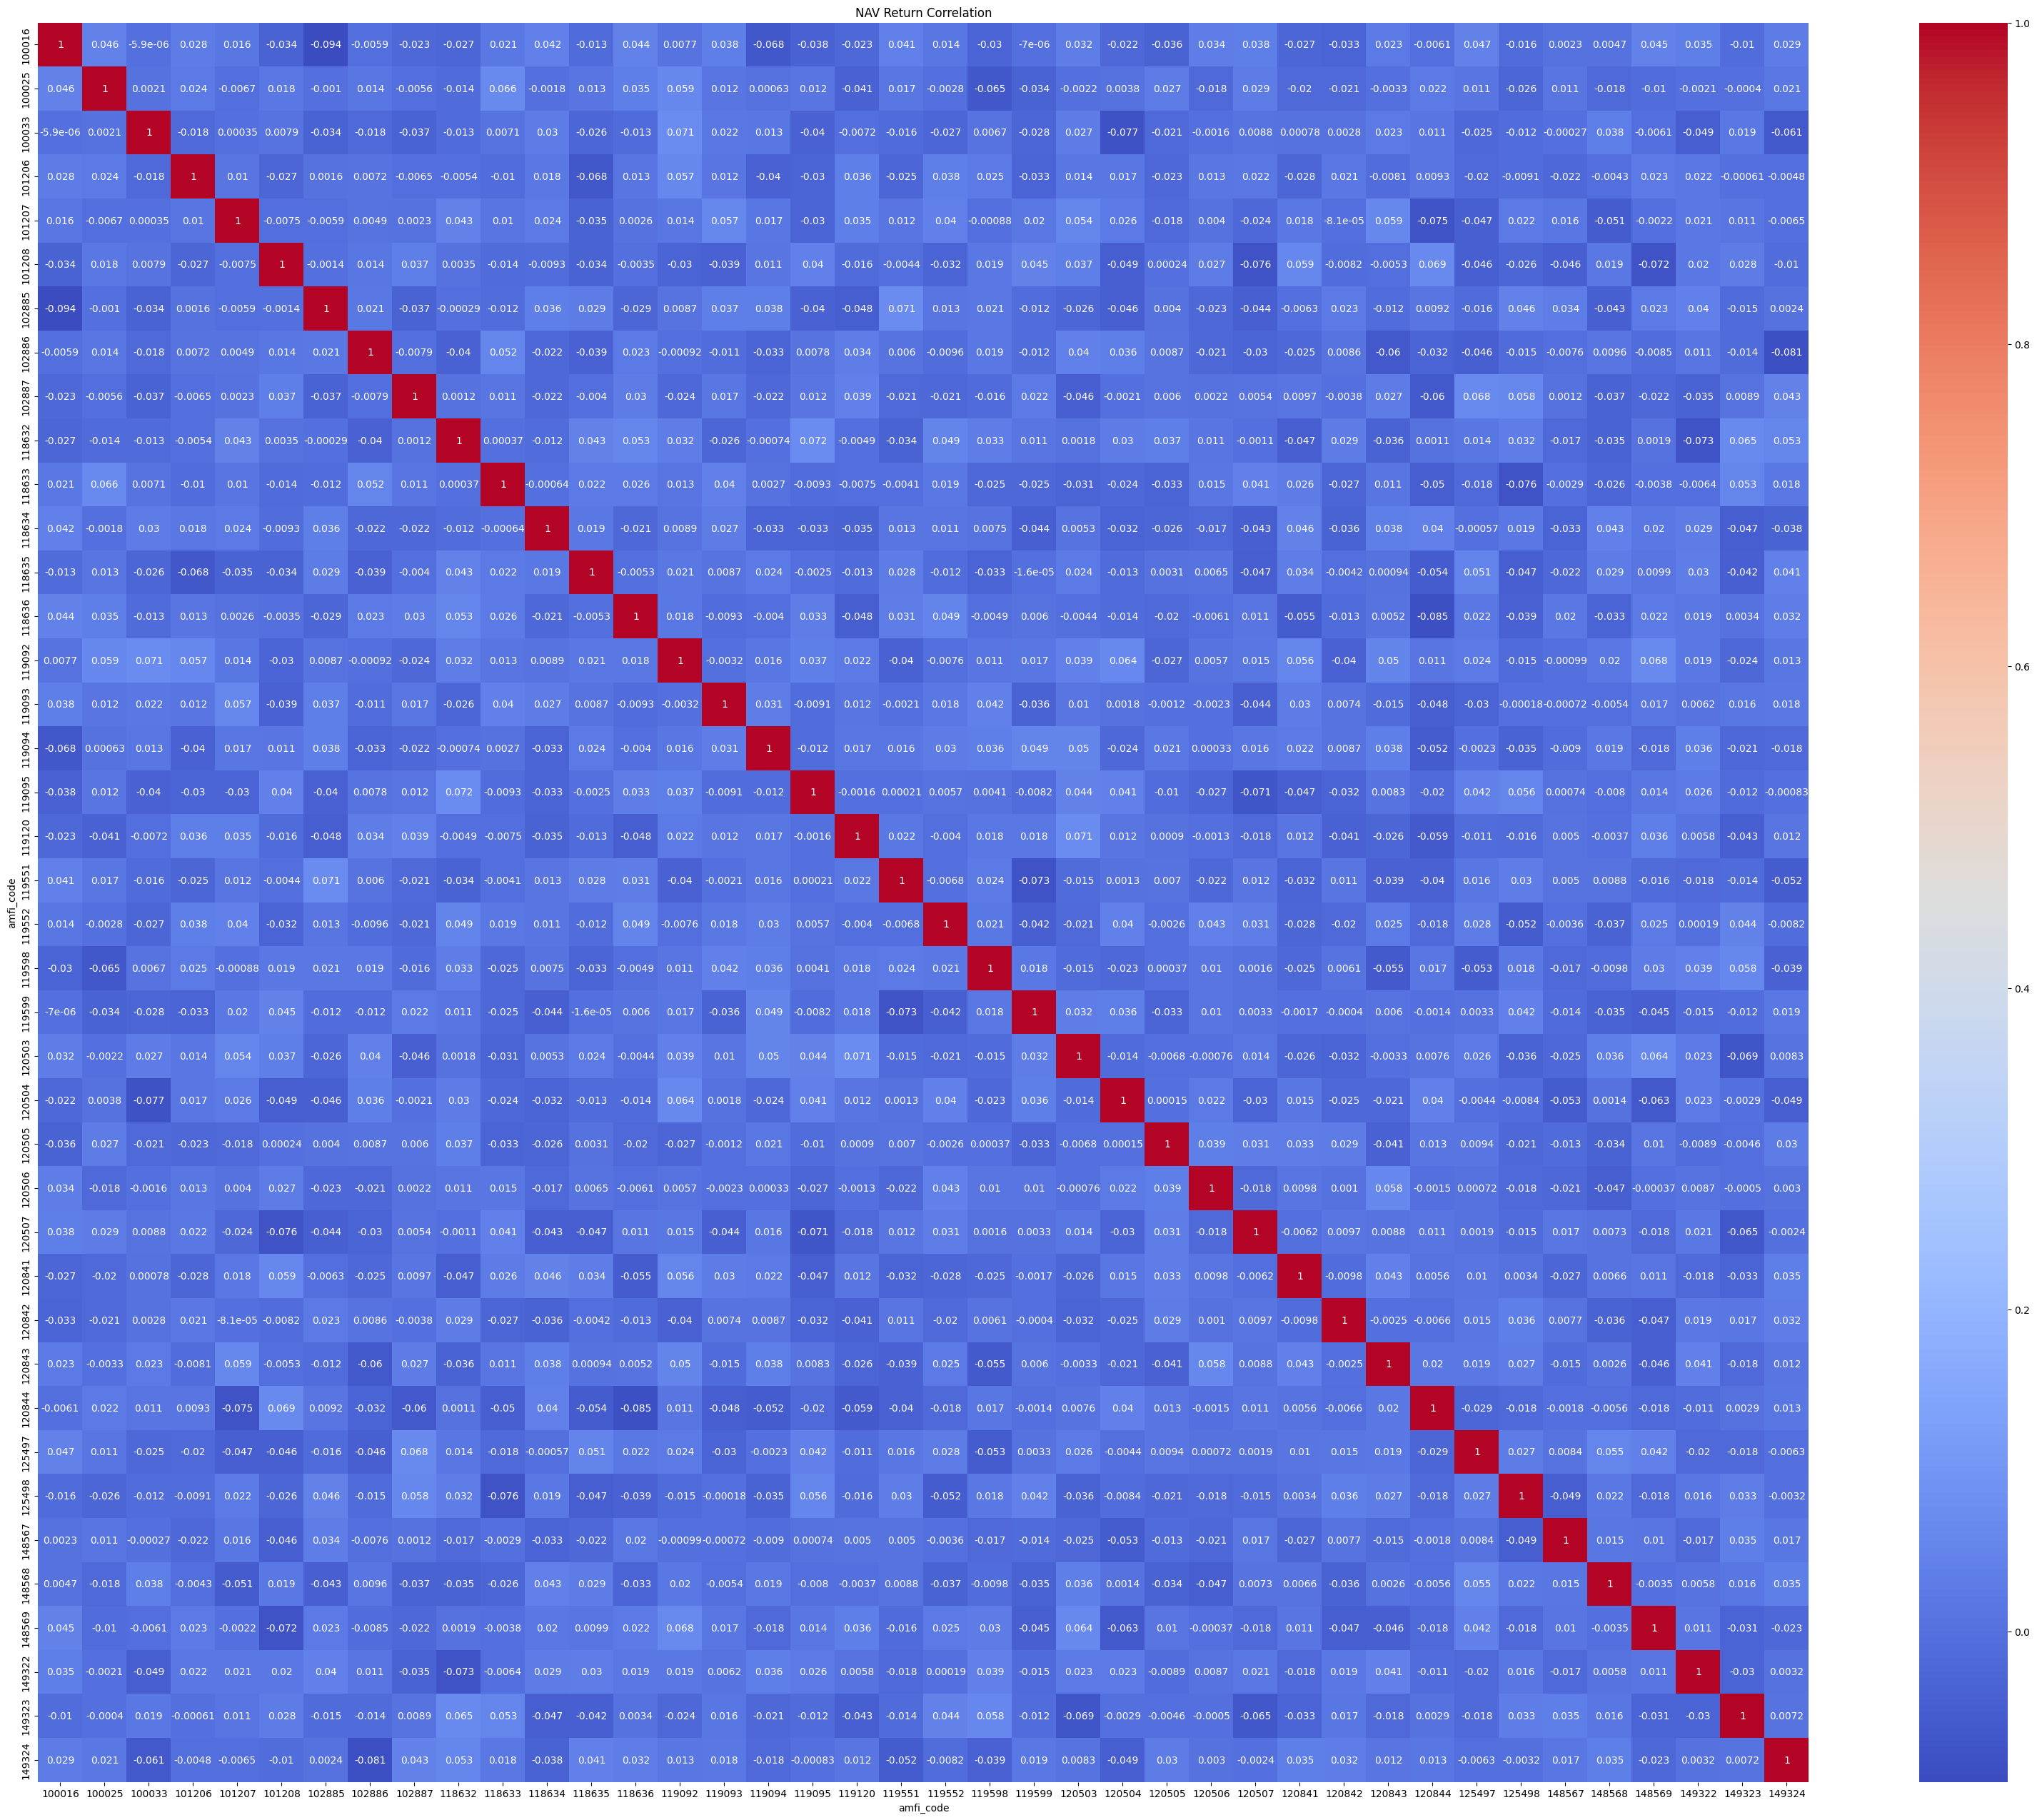

In [53]:
plt.figure(figsize=(40,32))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("NAV Return Correlation")
plt.show()

In [56]:
holdings = pd.read_csv("../data/processed/09_portfolio_holdings_cleaned.csv")
sector = holdings.groupby(
    'sector'
)['weight_pct'].sum()

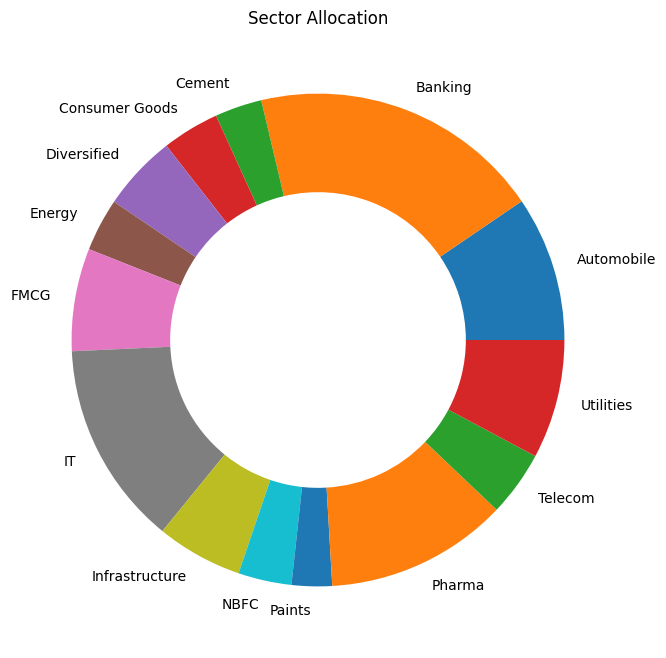

In [57]:
plt.figure(figsize=(8,8))

plt.pie(
    sector,
    labels=sector.index,
    wedgeprops={'width':0.4}
)

plt.title("Sector Allocation")
plt.show()